
# Parameter Sweep — Dataset Generator (3× per parameter)

This notebook runs the generator **three times per parameter** (keeping others at baseline) and
visualizes mid-slices in a big grid — **one row per parameter** and **three columns for the tested values**.

**Notes**  
- Compression is disabled (as requested).  
- We visualize **Channel 3** (grayscale) and overlay the **label map** edges.  
- For parameters affecting size, we resample to a common display size for consistent grids.
- Backend defaults to `None` in this demo; use `"egl"` only if your system supports it.

Run the next cells top-to-bottom.



## 0) Paths & imports
Update `GENERATOR_SCRIPT_PATH` if needed.


In [2]:

from pathlib import Path
import importlib.util, sys, shutil, os
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

# optional for resizing display images (only used when size is swept)
try:
    from skimage.transform import resize as imresize
except Exception:
    imresize = None

BASE_DIR = Path('./param_sweep_out').resolve()
BASE_DIR.mkdir(exist_ok=True, parents=True)

# Path to the (simplified) generator script
GENERATOR_SCRIPT_PATH = Path("example-data-generator.py")  # adjust if different
assert GENERATOR_SCRIPT_PATH.exists(), f"Generator not found at {GENERATOR_SCRIPT_PATH}"
GENERATOR_SCRIPT_PATH


PosixPath('example-data-generator.py')


## 1) Import the Click command from the generator


In [27]:

spec = importlib.util.spec_from_file_location("dataset_gen", str(GENERATOR_SCRIPT_PATH))
gen_mod = importlib.util.module_from_spec(spec)
sys.modules["dataset_gen"] = gen_mod
spec.loader.exec_module(gen_mod)

generate_cmd = gen_mod.generate_data  # Click command
generate_cmd


<Command generate-data>


## 2) Baseline configuration & parameter grid

- We keep a small **SIZE=64** for quick runs.
- We **disable compression** (`--compression none`).
- Backend remains `None` by default (works on most desktops). If you need EGL, set `BACKEND = "egl"` and ensure drivers.


In [22]:

# Baseline config (matches original behavior but quicker SIZE for demos)
OUT_ROOT = BASE_DIR
SIZE = 64
BACKEND = None       # or "egl"
SEED = 1             # fixed for reproducibility across sweeps
SEG1 = 40.0
SEG2 = 252.0
LBL  = 10.0

# Parameter grid: three values per parameter
# Feel free to tweak values to better expose effects in your tutorial.
PARAM_GRID = {
    "size": [128, 256, 512],                # affects volume shape; we downsample/upsample for display only
    # "seg1_threshold": [30.0, 40.0, 55.0],
    # "seg2_threshold": [230.0, 252.0, 255.0],
    # "label_threshold": [5.0, 10.0, 20.0],
    # "seed": [1, 7, 23],                  # changes random centers
}



## 3) Helper: run generator once with overrides


In [23]:

def run_once(out_dir: Path, **overrides):
    """Run the generator with baseline settings + overrides."""
    args = [str(out_dir)]
    # choose size
    size = overrides.get("size", SIZE)
    args += ["--size", str(size)]
    # backend
    backend = overrides.get("backend", BACKEND)
    if backend:
        args += ["--backend", str(backend)]
    # thresholds
    args += ["--seg1-threshold", str(overrides.get("seg1_threshold", SEG1))]
    args += ["--seg2-threshold", str(overrides.get("seg2_threshold", SEG2))]
    args += ["--label-threshold", str(overrides.get("label_threshold", LBL))]
    # seed (optional for reproducibility)
    seed = overrides.get("seed", SEED)
    if seed is not None:
        args += ["--seed", str(seed)]
    # call click command
    try:
        generate_cmd.main(args, standalone_mode=False)
    except SystemExit as e:
        if e.code != 0:
            raise



## 5) Run sweeps & visualize
Each row corresponds to one parameter. Columns show the three values (left→right).


In [28]:
import pyvista as pv
# Clean previous sweep outputs (optional)
for p in OUT_ROOT.glob("*"):
    if p.is_dir():
        shutil.rmtree(p)

n_rows = len(PARAM_GRID)
n_cols = 3

plotter = pv.Plotter(shape=(n_rows, n_cols))

for r, (param, values) in enumerate(PARAM_GRID.items()):
    for c, val in enumerate(values):
        out_dir = OUT_ROOT / f"{param}_{val}"
        out_dir.mkdir(parents=True, exist_ok=True)
        overrides = {param: val}
        run_once(out_dir, **overrides)
print("Done.")

Exporting to /media/data/Development/hi/repos/workshops/3d-data-visualization/notebooks/param_sweep_out/size_128..
Exporting to /media/data/Development/hi/repos/workshops/3d-data-visualization/notebooks/param_sweep_out/size_256..
Exporting to /media/data/Development/hi/repos/workshops/3d-data-visualization/notebooks/param_sweep_out/size_512..
Done.


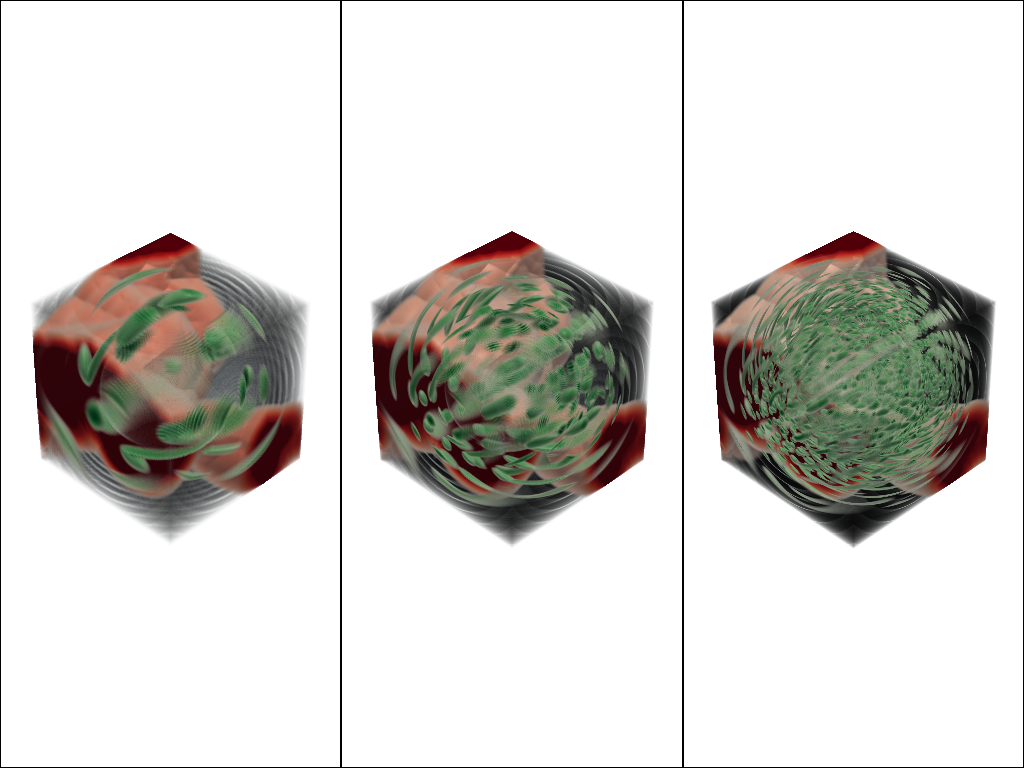

In [29]:
plotter = pv.Plotter(shape=(n_rows, n_cols))
for r, (param, values) in enumerate(PARAM_GRID.items()):
    for c, val in enumerate(values):
        out_dir = OUT_ROOT / f"{param}_{val}"
        plotter.subplot(r, c)
        plotter.add_volume(pv.wrap(tiff.imread(str(out_dir / "raw_channel1.tif"))), shade=True, cmap="Blues")
        plotter.add_volume(pv.wrap(tiff.imread(str(out_dir / "raw_channel2.tif"))), shade=True, cmap="Reds")
        plotter.add_volume(pv.wrap(tiff.imread(str(out_dir / "raw_channel3.tif"))), shade=True, cmap="Greens")
    # annotate row on the left
    # axes[r, 0].set_ylabel(row_title, fontsize=12, rotation=90, labelpad=18)

plotter.remove_scalar_bar()
plotter.show(screenshot='example_dataset_parameter_sweep.png', jupyter_backend="static")